# Notebook 02 — EDA : Analyse Exploratoire des Données
## Projet Machine Learning : Healthy Illusion
**Détection des produits alimentaires à "image saine trompeuse"**

---

### Objectifs de ce notebook
1. Exploration univariée de chaque variable (histogrammes, boxplots, stats)
2. Exploration bivariée (variables vs cible `bad_nutrition`)
3. Analyse spécifique du déséquilibre des classes
4. Identification des features signaux (avec test statistique Mann-Whitney)
5. Analyse de la variable métier `healthy_illusion`
6. Synthèse et recommandations pour le preprocessing (Phase 2)


## 0. Imports et configuration


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Couleurs du projet
COLOR_0 = '#4CAF50'   # classe majoritaire — bon (nutriscore A/B/C)
COLOR_1 = '#F44336'   # classe minoritaire — mauvais (nutriscore D/E)
COLORS  = [COLOR_0, COLOR_1]

print(' Imports OK')


 Imports OK


## 1. Chargement du dataset

Le dataset utilisé est le fichier final généré en Phase 1 : `data/dataset.csv`.


In [2]:
from pathlib import Path

PROJECT_ROOT = Path('..')
DATASET_PATH = PROJECT_ROOT / 'data' / 'dataset.csv'

df = pd.read_csv(DATASET_PATH)
print(f' Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
df.head()


 Dataset chargé : 15,079 lignes × 18 colonnes


,code,product_name,brands,main_category,country,sugars_100g,fat_100g,saturated_fat_100g,salt_100g,fiber_100g,proteins_100g,energy_kcal_100g,additives_count,has_labels,image_saine,nutriscore_grade,bad_nutrition,healthy_illusion
0,8013799003062,Lenticchia rossa decorticata,Bettini,plant-based-foods-and-beverages,italy,1.540000,1.500000,0.300000,0.020000,16.8,23.600000,321.000000,0,1,1,a,0,0
1,5400111101620,Couscous Semoule De Blé Dur Bio,Delhaize,plant-based-foods-and-beverages,belgium,3.900000,1.800000,0.300000,0.000000,4.0,13.000000,364.000000,0,1,1,a,0,0
2,3266191090009,Boisson au Riz Nature,La Vie Claire,plant-based-foods-and-beverages,france,7.000000,1.000000,0.100000,0.100000,0.7,0.400000,56.000000,0,1,1,d,1,1
3,5020580400101,Basmati rice,Laila,plant-based-foods-and-beverages,france,0.166667,0.833333,0.166667,0.166667,NaN,8.166667,376.666667,0,1,1,b,0,0
4,3258561211510,Lentilles cuisinés,"Belle France, Francap Distribution",plant-based-foods-and-beverages,france,1.100000,2.500000,0.700000,0.860000,2.5,5.700000,90.000000,1,1,1,c,0,0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   code                15079 non-null  object 
 1   product_name        14806 non-null  object 
 2   brands              14675 non-null  object 
 3   main_category       15079 non-null  object 
 4   country             15079 non-null  object 
 5   sugars_100g         15046 non-null  float64
 6   fat_100g            15079 non-null  float64
 7   saturated_fat_100g  14981 non-null  float64
 8   salt_100g           15052 non-null  float64
 9   fiber_100g          11116 non-null  float64
 10  proteins_100g       15077 non-null  float64
 11  energy_kcal_100g    15067 non-null  float64
 12  additives_count     15079 non-null  int64  
 13  has_labels          15079 non-null  int64  
 14  image_saine         15079 non-null  int64  
 15  nutriscore_grade    15079 non-null  object 
 16  bad_

In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
code,15079,15079,8013799003062,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name,14806,12000,Couscous,113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brands,14675,4789,Carrefour,352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
main_category,15079,13,plant-based-foods-and-beverages,7947,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,15079,101,france,8055,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sugars_100g,15046.0,NaN,NaN,NaN,6.272308,8.201556,0.0,0.560845,3.5,9.6,92.592593
fat_100g,15079.0,NaN,NaN,NaN,4.844776,9.015324,0.0,0.5,1.8,4.5,100.0
saturated_fat_100g,14981.0,NaN,NaN,NaN,1.648274,3.707339,0.0,0.1,0.4,1.7,39.0
salt_100g,15052.0,NaN,NaN,NaN,0.386654,1.417263,0.0,0.01,0.1,0.543125,98.35
fiber_100g,11116.0,NaN,NaN,NaN,3.574395,4.644309,0.0,0.4,1.9,5.5,86.7


## 2. Définition des variables

On distingue clairement :
- **Variable cible** : `bad_nutrition` (0 = bon nutriscore A/B/C, 1 = mauvais nutriscore D/E)
- **Variables numériques** : valeurs nutritionnelles pour 100g
- **Variables catégorielles** : catégorie, pays, labels
- **Colonnes exclues** : identifiants, variables dérivées (data leakage)


In [5]:
# Variable cible
TARGET = 'bad_nutrition'

# Features numériques
NUM_COLS = [
    'sugars_100g', 'fat_100g', 'saturated_fat_100g',
    'salt_100g', 'fiber_100g', 'proteins_100g',
    'energy_kcal_100g', 'additives_count'
]

# Features catégorielles
CAT_COLS = ['main_category', 'country', 'has_labels', 'image_saine']

# Colonnes exclues de la modélisation (identifiants + leakage)
EXCLUDED = ['code', 'product_name', 'brands', 'nutriscore_grade', 'healthy_illusion']
# Justification des exclusions :
# - code / product_name / brands : identifiants, non informatifs
# - nutriscore_grade : construit directement depuis les nutriments → data leakage
# - healthy_illusion : variable dérivée de bad_nutrition + image_saine → data leakage

print(f'Cible             : {TARGET}')
print(f'Features num.     : {NUM_COLS}')
print(f'Features cat.     : {CAT_COLS}')
print(f'Colonnes exclues  : {EXCLUDED}')


Cible             : bad_nutrition
Features num.     : ['sugars_100g', 'fat_100g', 'saturated_fat_100g', 'salt_100g', 'fiber_100g', 'proteins_100g', 'energy_kcal_100g', 'additives_count']
Features cat.     : ['main_category', 'country', 'has_labels', 'image_saine']
Colonnes exclues  : ['code', 'product_name', 'brands', 'nutriscore_grade', 'healthy_illusion']


## 3. Analyse des doublons

On vérifie les doublons exacts et les doublons sur le code produit (identifiant unique).


In [6]:
# Doublons exacts (toutes colonnes identiques)
nb_dup_exact = df.duplicated().sum()
print(f'Doublons exacts         : {nb_dup_exact}')

# Doublons sur le code produit
nb_dup_code = df['code'].duplicated().sum()
print(f'Codes produits dupliqués: {nb_dup_code}')

if nb_dup_exact == 0 and nb_dup_code == 0:
    print(' Aucun doublon détecté.')
else:
    print(' Des doublons sont présents — à traiter en Phase 2 (03_preprocessing.ipynb).')


Doublons exacts         : 0
Codes produits dupliqués: 0
 Aucun doublon détecté.


## 4. Valeurs manquantes

On quantifie le taux de valeurs manquantes par colonne et on propose une stratégie de traitement.
Les décisions finales seront appliquées dans `03_preprocessing.ipynb`.


=== 8 colonne(s) avec valeurs manquantes ===


,Valeurs manquantes,Pourcentage (%),Stratégie proposée
fiber_100g,3963,26.28,Imputer médiane/mode
brands,404,2.68,Supprimer ligne
product_name,273,1.81,Supprimer ligne
saturated_fat_100g,98,0.65,Supprimer ligne
sugars_100g,33,0.22,Supprimer ligne
salt_100g,27,0.18,Supprimer ligne
energy_kcal_100g,12,0.08,Supprimer ligne
proteins_100g,2,0.01,Supprimer ligne


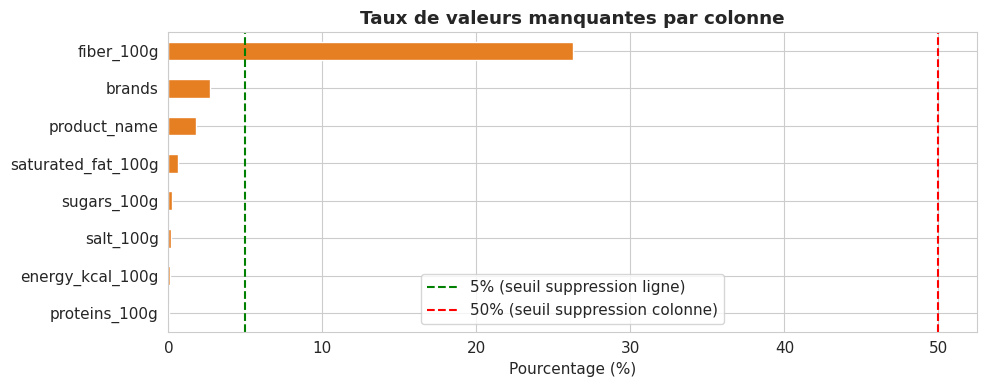

In [7]:
manq     = df.isnull().sum()
manq_pct = (manq / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Valeurs manquantes': manq,
    'Pourcentage (%)': manq_pct,
    'Stratégie proposée': [
        ' Aucune action' if p == 0
        else ('Supprimer ligne' if p < 5
        else ('Supprimer colonne' if p > 50
        else 'Imputer médiane/mode'))
        for p in manq_pct
    ]
}).sort_values('Pourcentage (%)', ascending=False)

missing_avec = missing_df[missing_df['Valeurs manquantes'] > 0]
if len(missing_avec) > 0:
    print(f'=== {len(missing_avec)} colonne(s) avec valeurs manquantes ===')
    display(missing_avec)

    # Graphique
    fig, ax = plt.subplots(figsize=(10, 4))
    manq_pct[manq_pct > 0].sort_values().plot(kind='barh', ax=ax, color='#E67E22')
    ax.axvline(5,  color='green', linestyle='--', linewidth=1.5, label='5% (seuil suppression ligne)')
    ax.axvline(50, color='red',   linestyle='--', linewidth=1.5, label='50% (seuil suppression colonne)')
    ax.set_title('Taux de valeurs manquantes par colonne', fontweight='bold')
    ax.set_xlabel('Pourcentage (%)')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(' Aucune valeur manquante dans le dataset.')


## 5. Distribution de la cible — Analyse du déséquilibre

La variable cible est `bad_nutrition` :
- `0` : produit avec bon nutriscore (A, B ou C)
- `1` : produit avec mauvais nutriscore (D ou E)

Cette analyse est **obligatoire** selon le descriptif de la Phase 2.


In [8]:
vc  = df[TARGET].value_counts().sort_index()
pct = df[TARGET].value_counts(normalize=True).sort_index() * 100

print('='*55)
print('ANALYSE DU DÉSÉQUILIBRE — bad_nutrition')
print('='*55)
print(f'\n  Total produits          : {len(df):,}')
print(f'  bad_nutrition = 0 (bon) : {vc[0]:,}  ({pct[0]:.1f}%)')
print(f'  bad_nutrition = 1 (mauvais) : {vc[1]:,}  ({pct[1]:.1f}%)')
print(f'\n  Ratio déséquilibre : 1 mauvais pour {vc[0]//vc[1]} bons')

ratio_min = pct.min()
if 5 <= ratio_min <= 25:
    print(f'\n  Classe minoritaire = {ratio_min:.1f}% — CONFORME (entre 5% et 25%)')
else:
    print(f'\n  Classe minoritaire = {ratio_min:.1f}% — NON CONFORME')


ANALYSE DU DÉSÉQUILIBRE — bad_nutrition

  Total produits          : 15,079
  bad_nutrition = 0 (bon) : 12,447  (82.5%)
  bad_nutrition = 1 (mauvais) : 2,632  (17.5%)

  Ratio déséquilibre : 1 mauvais pour 4 bons

  Classe minoritaire = 17.5% — CONFORME (entre 5% et 25%)


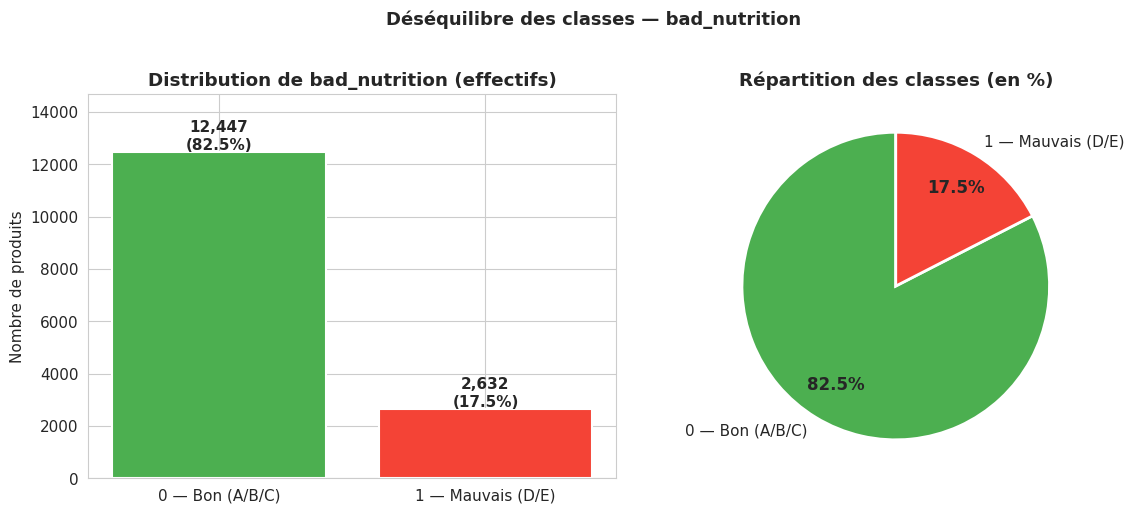

In [9]:
# Visualisation : barres + camembert
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Barres ---
bars = axes[0].bar(
    ['0 — Bon (A/B/C)', '1 — Mauvais (D/E)'],
    [vc[0], vc[1]], color=COLORS, edgecolor='white', linewidth=1.5
)
axes[0].set_title('Distribution de bad_nutrition (effectifs)', fontweight='bold')
axes[0].set_ylabel('Nombre de produits')
for bar, val, p in zip(bars, [vc[0], vc[1]], [pct[0], pct[1]]):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max(vc)*0.01,
        f'{val:,}\n({p:.1f}%)', ha='center', fontweight='bold', fontsize=11
    )
axes[0].set_ylim(0, max(vc)*1.18)

# --- Camembert ---
wedges, texts, autotexts = axes[1].pie(
    [vc[0], vc[1]],
    labels=['0 — Bon (A/B/C)', '1 — Mauvais (D/E)'],
    colors=COLORS, autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2}, pctdistance=0.75
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(12)
axes[1].set_title('Répartition des classes (en %)', fontweight='bold')

plt.suptitle('Déséquilibre des classes — bad_nutrition', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 6. Exploration univariée — Variables numériques

Pour chaque variable numérique : histogramme + boxplot côte à côte, avec moyenne et médiane annotées.


In [10]:
# Tableau de statistiques descriptives complet
stats_df = pd.DataFrame({
    'Moyenne'    : df[NUM_COLS].mean().round(2),
    'Médiane'    : df[NUM_COLS].median().round(2),
    'Écart-type' : df[NUM_COLS].std().round(2),
    'Min'        : df[NUM_COLS].min().round(2),
    'Q1 (25%)'   : df[NUM_COLS].quantile(0.25).round(2),
    'Q3 (75%)'   : df[NUM_COLS].quantile(0.75).round(2),
    'Max'        : df[NUM_COLS].max().round(2),
})
print('=== Statistiques descriptives — Variables numériques ===')
display(stats_df)


=== Statistiques descriptives — Variables numériques ===


,Moyenne,Médiane,Écart-type,Min,Q1 (25%),Q3 (75%),Max
sugars_100g,6.27,3.5,8.20,0.0,0.56,9.60,92.59
fat_100g,4.84,1.8,9.02,0.0,0.50,4.50,100.00
saturated_fat_100g,1.65,0.4,3.71,0.0,0.10,1.70,39.00
salt_100g,0.39,0.1,1.42,0.0,0.01,0.54,98.35
fiber_100g,3.57,1.9,4.64,0.0,0.40,5.50,86.70
proteins_100g,6.78,5.3,6.62,0.0,1.60,9.40,85.00
energy_kcal_100g,185.78,110.0,158.99,0.0,57.00,350.00,975.78
additives_count,0.59,0.0,1.27,0.0,0.00,1.00,14.00


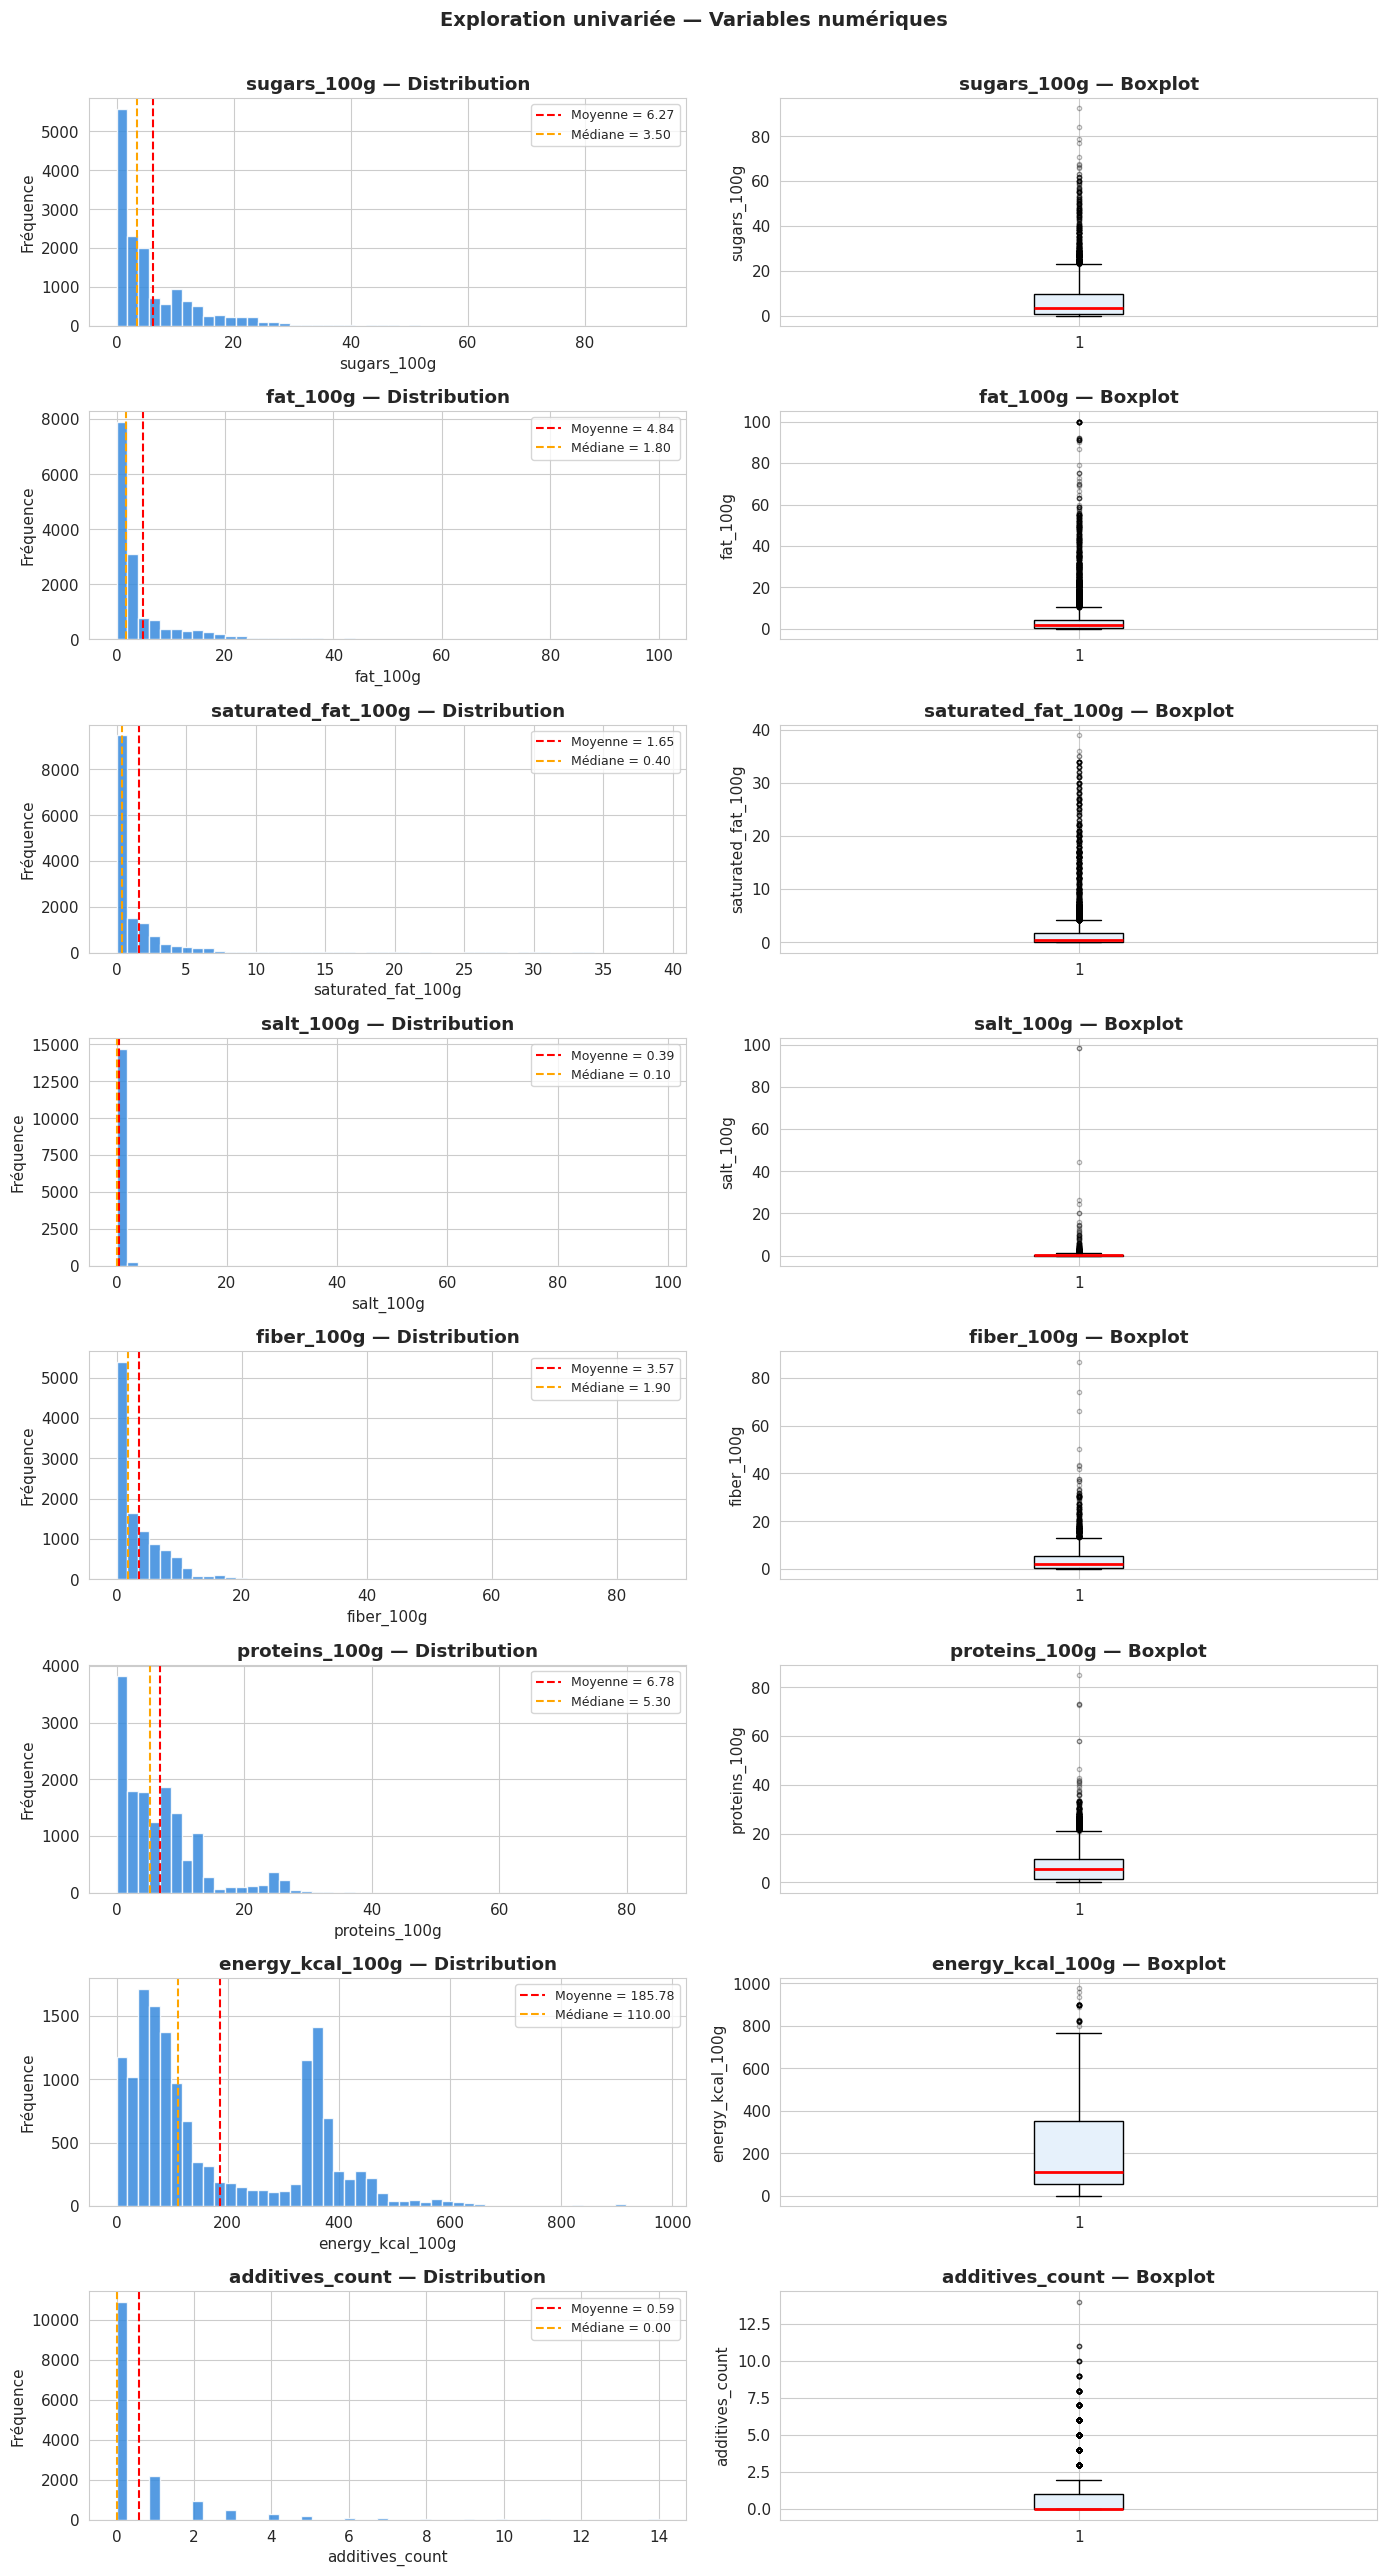

In [11]:
# Histogramme + boxplot côte à côte pour chaque variable numérique
fig, axes = plt.subplots(len(NUM_COLS), 2, figsize=(14, len(NUM_COLS)*3.2))

for i, col in enumerate(NUM_COLS):
    data = df[col].dropna()
    mean_val   = data.mean()
    median_val = data.median()

    # --- Histogramme ---
    axes[i, 0].hist(data, bins=50, color='#378ADD', edgecolor='white', alpha=0.85)
    axes[i, 0].axvline(mean_val,   color='red',    linestyle='--', linewidth=1.5,
                       label=f'Moyenne = {mean_val:.2f}')
    axes[i, 0].axvline(median_val, color='orange', linestyle='--', linewidth=1.5,
                       label=f'Médiane = {median_val:.2f}')
    axes[i, 0].set_title(f'{col} — Distribution', fontweight='bold')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Fréquence')
    axes[i, 0].legend(fontsize=9)

    # --- Boxplot ---
    bp = axes[i, 1].boxplot(data, vert=True, patch_artist=True,
                             boxprops=dict(facecolor='#E6F1FB'),
                             medianprops=dict(color='red', linewidth=2),
                             flierprops=dict(marker='o', markersize=3, alpha=0.3))
    axes[i, 1].set_title(f'{col} — Boxplot', fontweight='bold')
    axes[i, 1].set_ylabel(col)

plt.suptitle('Exploration univariée — Variables numériques', fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()


## 7. Exploration univariée — Variables catégorielles

Pour chaque variable catégorielle : fréquences, identification des **modalités rares** (< 1%).



Variable : main_category
Modalités uniques : 13
 Modalités rares (< 1%) : 6 modalités → à regrouper en "other"


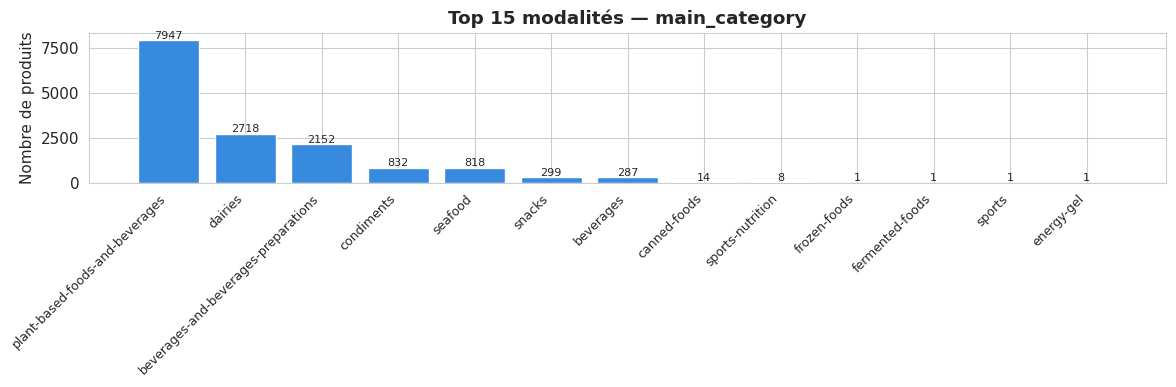


Variable : country
Modalités uniques : 101
 Modalités rares (< 1%) : 89 modalités → à regrouper en "other"


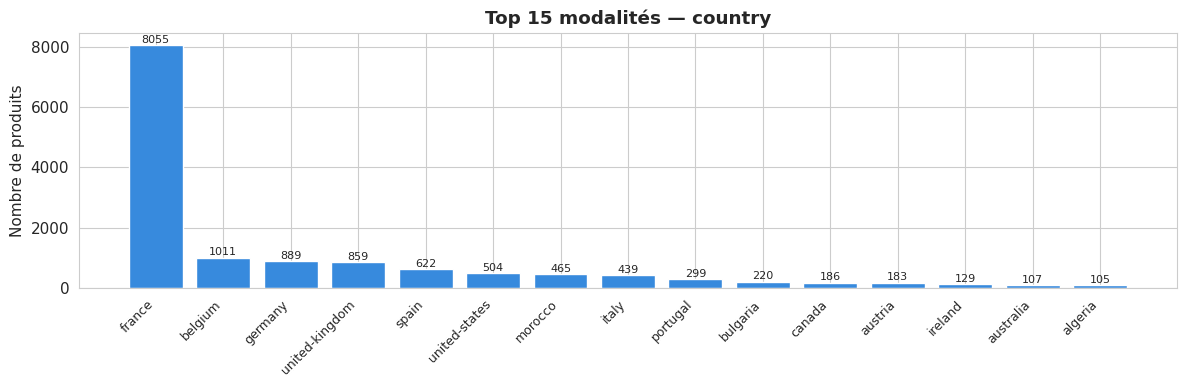


Variable : has_labels
Modalités uniques : 2
 Aucune modalité rare


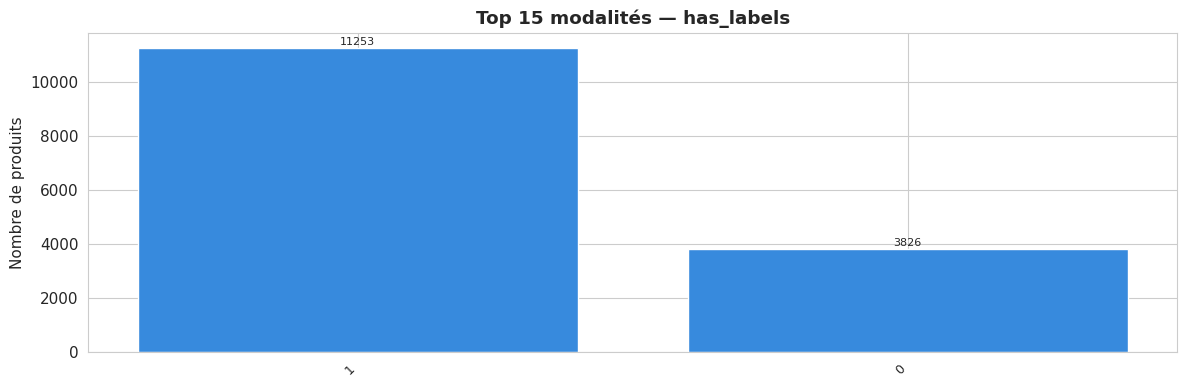


Variable : image_saine
Modalités uniques : 2
 Aucune modalité rare


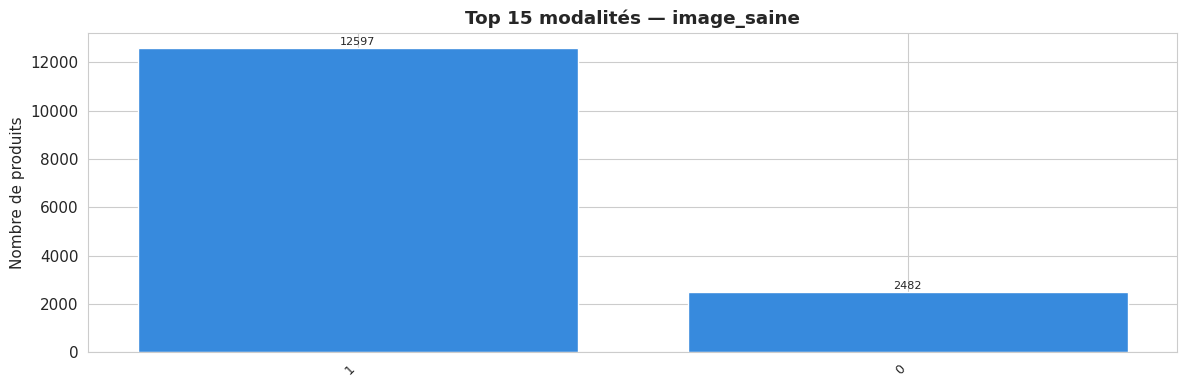


=== Récapitulatif — Modalités rares ===


,Variable,Nb modalités totales,Nb modalités rares (<1%),% modalités rares
0,main_category,13,6,46.2
1,country,101,89,88.1
2,has_labels,2,0,0.0
3,image_saine,2,0,0.0


In [12]:
rare_summary = []

for col in CAT_COLS:
    vc_col  = df[col].value_counts()
    pct_col = df[col].value_counts(normalize=True) * 100
    rares   = pct_col[pct_col < 1]
    n_mod   = df[col].nunique()

    print(f"\n{'='*55}")
    print(f'Variable : {col}')
    print(f'Modalités uniques : {n_mod}')
    if len(rares) > 0:
        print(f' Modalités rares (< 1%) : {len(rares)} modalités → à regrouper en "other"')
    else:
        print(' Aucune modalité rare')

    # Top 15
    top15 = vc_col.head(15)
    fig, ax = plt.subplots(figsize=(12, 4))
    bars = ax.bar(range(len(top15)), top15.values, color='#378ADD', edgecolor='white')
    ax.set_xticks(range(len(top15)))
    ax.set_xticklabels(top15.index, rotation=45, ha='right', fontsize=9)
    ax.set_title(f'Top 15 modalités — {col}', fontweight='bold')
    ax.set_ylabel('Nombre de produits')
    for bar, val in zip(bars, top15.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(top15)*0.01,
                str(val), ha='center', fontsize=8)
    plt.tight_layout()
    plt.show()

    rare_summary.append({
        'Variable': col,
        'Nb modalités totales': n_mod,
        'Nb modalités rares (<1%)': len(rares),
        '% modalités rares': round(len(rares)/n_mod*100, 1) if n_mod > 0 else 0
    })

print('\n=== Récapitulatif — Modalités rares ===')
display(pd.DataFrame(rare_summary))


## 8. Exploration bivariée — Variables numériques × cible

Boxplot de chaque variable par classe, avec **test statistique Mann-Whitney** pour valider la significativité.


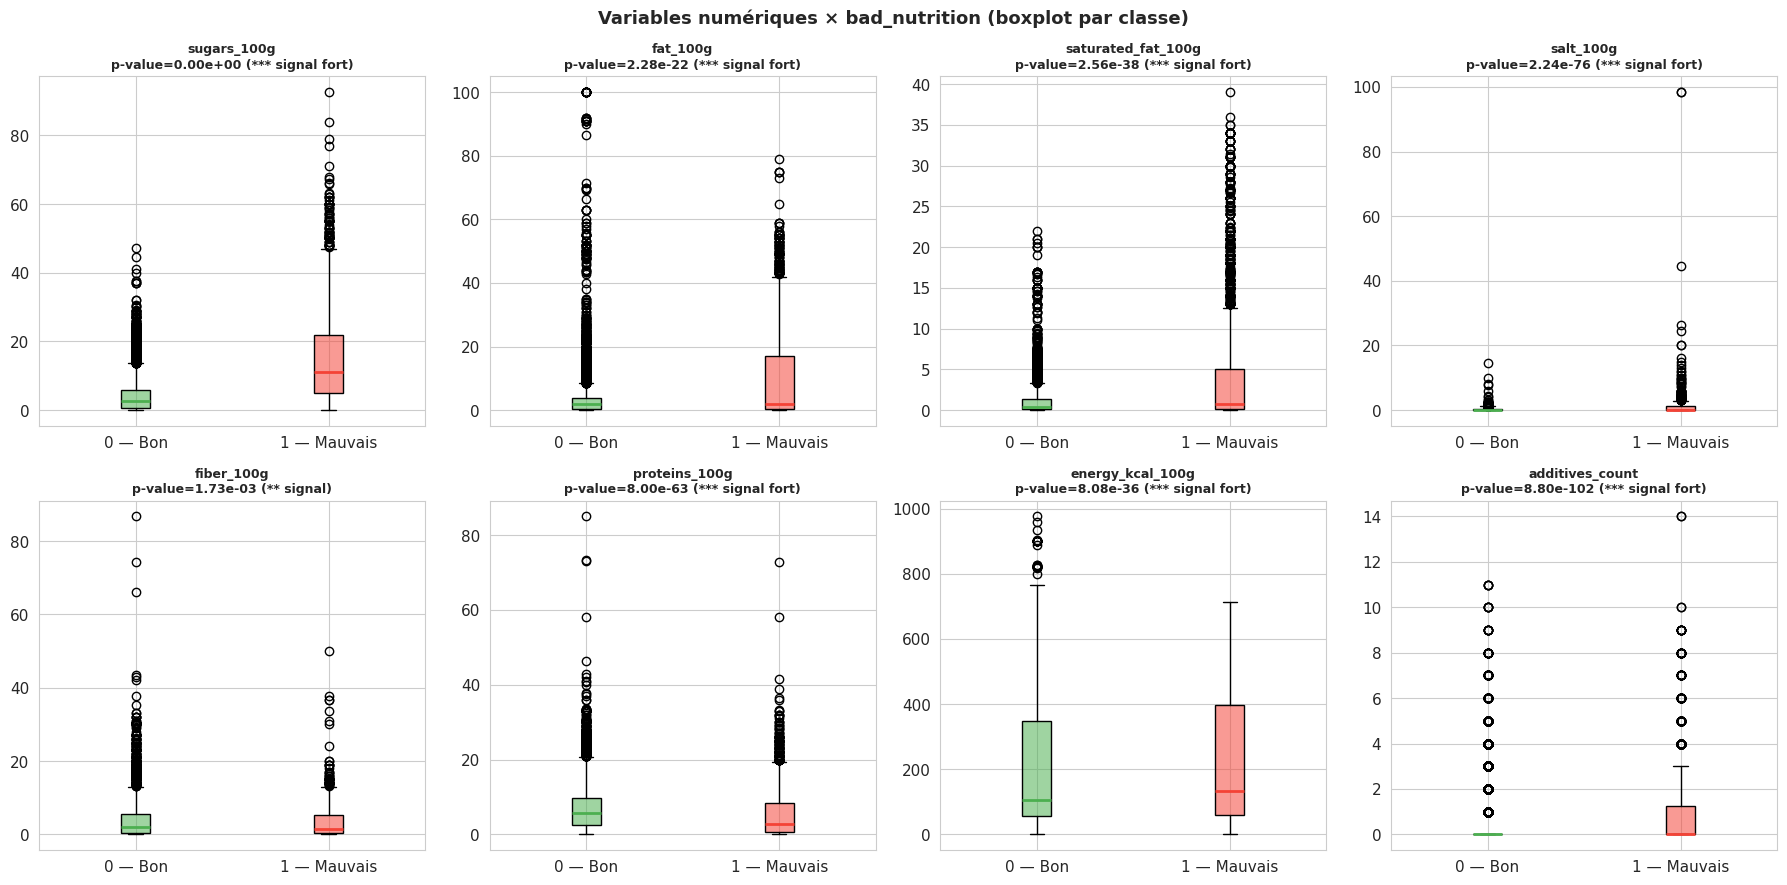

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    data0 = df[df[TARGET]==0][col].dropna()
    data1 = df[df[TARGET]==1][col].dropna()

    bp = axes[i].boxplot(
        [data0, data1],
        labels=['0 — Bon', '1 — Mauvais'],
        patch_artist=True,
        medianprops=dict(linewidth=2)
    )
    bp['boxes'][0].set_facecolor(COLOR_0 + '88')
    bp['boxes'][1].set_facecolor(COLOR_1 + '88')
    bp['medians'][0].set_color(COLOR_0)
    bp['medians'][1].set_color(COLOR_1)

    # Test Mann-Whitney
    stat, pval = stats.mannwhitneyu(data0, data1, alternative='two-sided')
    sig = '*** signal fort' if pval < 0.001 else ('** signal' if pval < 0.01 else 'ns')
    axes[i].set_title(f'{col}\np-value={pval:.2e} ({sig})', fontweight='bold', fontsize=9)

plt.suptitle('Variables numériques × bad_nutrition (boxplot par classe)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [14]:
# Statistiques moyennes par classe
df0 = df[df[TARGET]==0][NUM_COLS]
df1 = df[df[TARGET]==1][NUM_COLS]

stats_compare = pd.DataFrame({
    'Moy. bad=0 (bon)'     : df0.mean().round(2),
    'Moy. bad=1 (mauvais)' : df1.mean().round(2),
    'Diff. absolue'         : (df1.mean() - df0.mean()).round(2),
    'Ratio (mauvais/bon)'   : (df1.mean() / (df0.mean() + 0.001)).round(2),
})

print('=== Statistiques par classe ===')
print('Interprétation : Ratio > 1.5 ou < 0.7 = potentiel feature signal')
display(stats_compare)


=== Statistiques par classe ===
Interprétation : Ratio > 1.5 ou < 0.7 = potentiel feature signal


,Moy. bad=0 (bon),Moy. bad=1 (mauvais),Diff. absolue,Ratio (mauvais/bon)
sugars_100g,4.49,14.71,10.22,3.28
fat_100g,3.78,9.89,6.11,2.62
saturated_fat_100g,1.06,4.47,3.42,4.23
salt_100g,0.28,0.90,0.62,3.24
fiber_100g,3.64,3.26,-0.37,0.90
proteins_100g,7.10,5.25,-1.85,0.74
energy_kcal_100g,177.70,224.01,46.31,1.26
additives_count,0.49,1.07,0.58,2.19


## 9. Exploration bivariée — Variables catégorielles × cible

Tableau croisé et taux de classe positive (`bad_nutrition = 1`) par modalité.



Variable : main_category × bad_nutrition


,% bad=0 (bon),% bad=1 (mauvais)
main_category,,
fermented-foods,0.0,100.0
sports,0.0,100.0
snacks,15.1,84.9
sports-nutrition,25.0,75.0
condiments,62.3,37.7
beverages-and-beverages-preparations,65.4,34.6
seafood,85.2,14.8
beverages,86.8,13.2
plant-based-foods-and-beverages,87.2,12.8


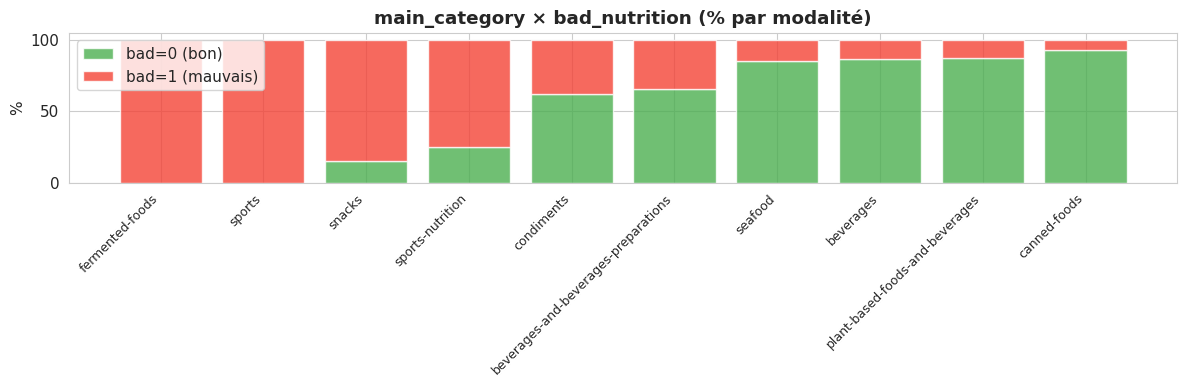


Variable : country × bad_nutrition


,% bad=0 (bon),% bad=1 (mauvais)
country,,
armenia,0.0,100.0
costa-rica,0.0,100.0
guernsey,0.0,100.0
moldova,0.0,100.0
kuwait,33.3,66.7
world,33.3,66.7
slovenia,33.3,66.7
afghanistan,42.9,57.1
senegal,50.0,50.0


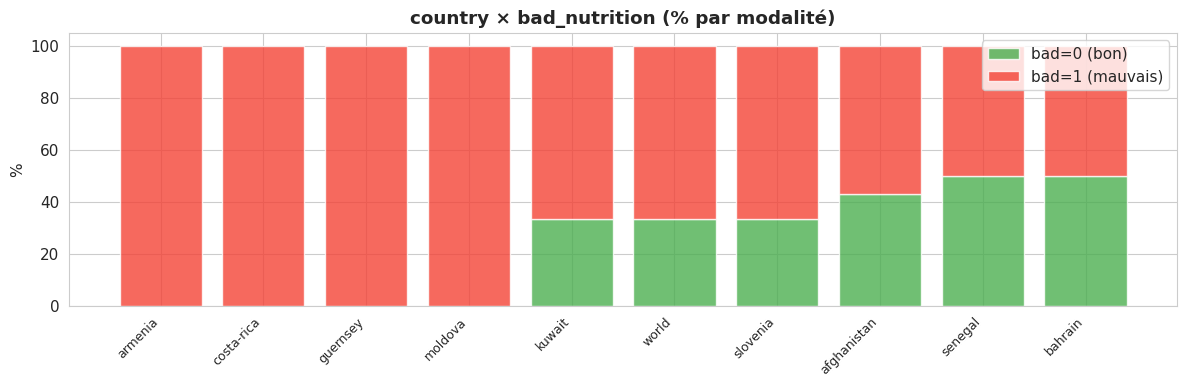


Variable : image_saine × bad_nutrition


,% bad=0 (bon),% bad=1 (mauvais)
image_saine,,
0,77.8,22.2
1,83.5,16.5


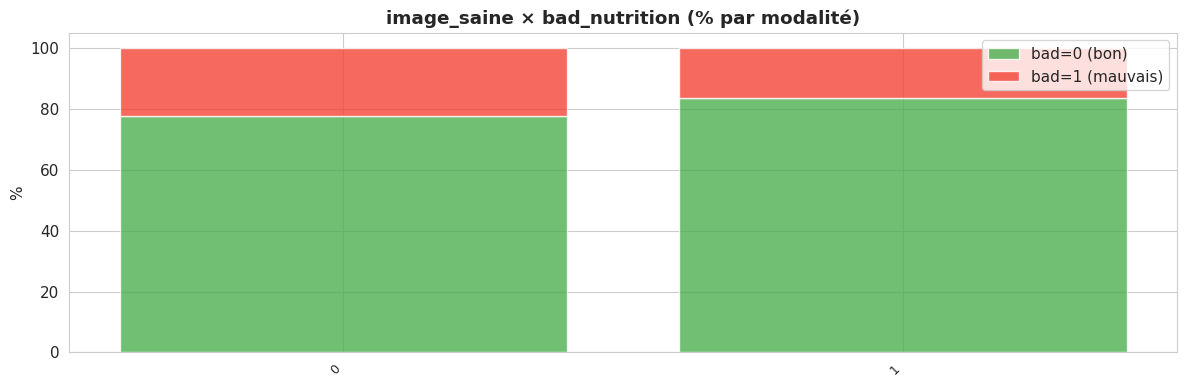


Variable : has_labels × bad_nutrition


,% bad=0 (bon),% bad=1 (mauvais)
has_labels,,
0,82.4,17.6
1,82.6,17.4


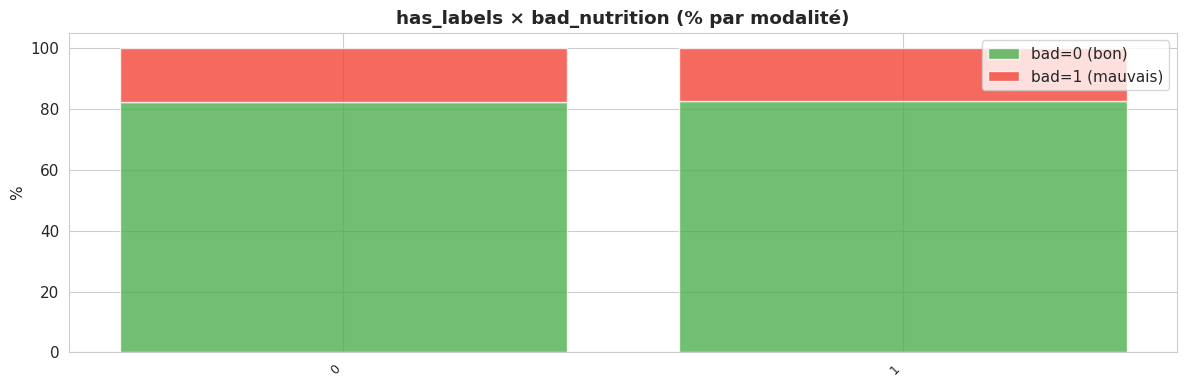

In [15]:
for col in ['main_category', 'country', 'image_saine', 'has_labels']:
    print(f"\n{'='*55}")
    print(f'Variable : {col} × {TARGET}')

    crosstab = pd.crosstab(df[col], df[TARGET], normalize='index') * 100
    crosstab.columns = ['% bad=0 (bon)', '% bad=1 (mauvais)']

    top = crosstab.sort_values('% bad=1 (mauvais)', ascending=False)
    if df[col].nunique() > 10:
        top = top.head(10)
    display(top.round(1))

    # Graphique
    fig, ax = plt.subplots(figsize=(12, 4))
    x = range(len(top))
    ax.bar(x, top['% bad=0 (bon)'],    color=COLOR_0, label='bad=0 (bon)',     alpha=0.8)
    ax.bar(x, top['% bad=1 (mauvais)'], color=COLOR_1, label='bad=1 (mauvais)', alpha=0.8,
           bottom=top['% bad=0 (bon)'])
    ax.set_xticks(x)
    ax.set_xticklabels(top.index, rotation=45, ha='right', fontsize=9)
    ax.set_title(f'{col} × bad_nutrition (% par modalité)', fontweight='bold')
    ax.set_ylabel('%')
    ax.legend()
    plt.tight_layout()
    plt.show()


## 10. Matrice de corrélation — Variables numériques

Heatmap annotée avec `seaborn`. On identifie les variables fortement corrélées entre elles (|r| > 0.7).


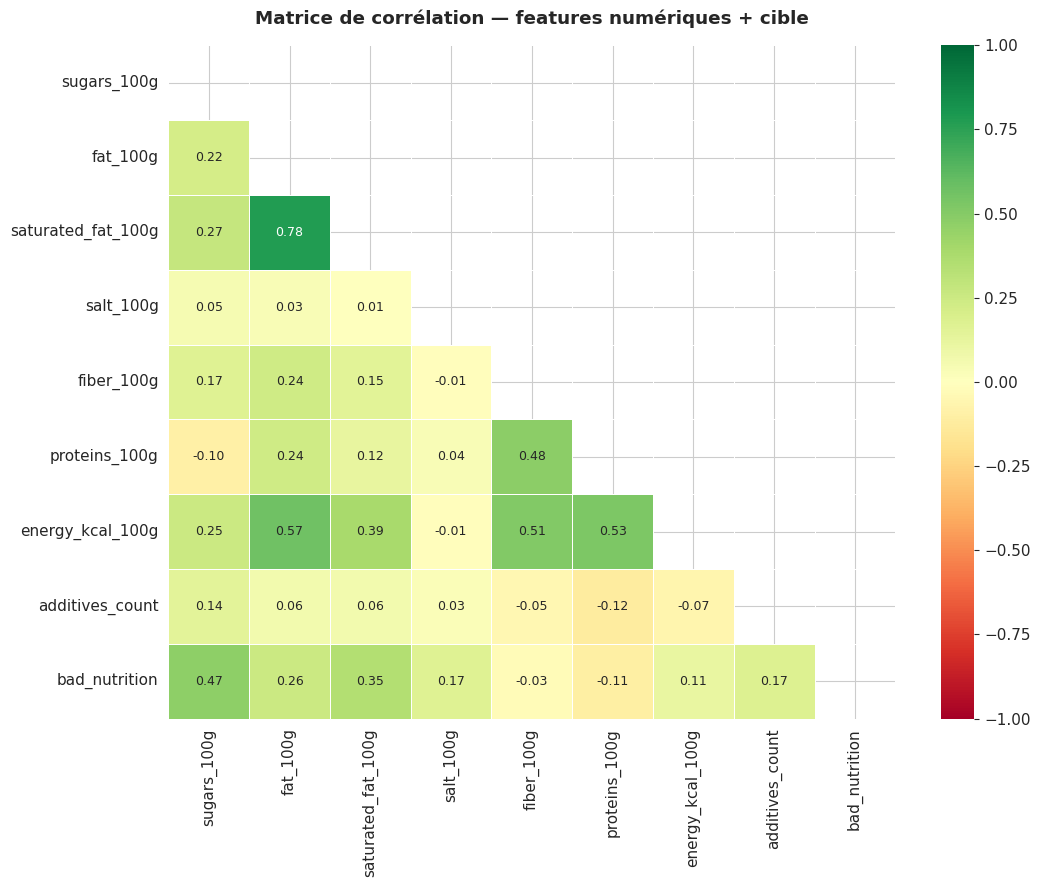


Corrélations fortes (|r| > 0.7) entre features :
  fat_100g × saturated_fat_100g → r = 0.78   forte corrélation


In [16]:
corr_matrix = df[NUM_COLS + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.5, annot_kws={'size': 9}
)
ax.set_title('Matrice de corrélation — features numériques + cible', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Corrélations fortes entre features
print('\nCorrélations fortes (|r| > 0.7) entre features :')
found = False
for i, c1 in enumerate(NUM_COLS):
    for j, c2 in enumerate(NUM_COLS):
        if j <= i: continue
        r = corr_matrix.loc[c1, c2]
        if abs(r) > 0.7:
            print(f'  {c1} × {c2} → r = {r:.2f}   forte corrélation')
            found = True
if not found:
    print('  Aucune corrélation > 0.7 détectée entre les features.')


## 11. Identification des features signaux

Les **features signaux** sont les variables pour lesquelles la classe minoritaire (`bad_nutrition = 1`)
se comporte **clairement différemment** de la classe majoritaire.

Critères retenus :
- Test Mann-Whitney : **p-value < 0.001** (différence statistiquement significative)
- Ratio des moyennes : **> 1.3** ou **< 0.7** (différence pratique suffisante)


In [17]:
print('=== FEATURES SIGNAUX — Test Mann-Whitney ===\n')

signals = []
for col in NUM_COLS:
    d0 = df[df[TARGET]==0][col].dropna()
    d1 = df[df[TARGET]==1][col].dropna()

    stat, pval = stats.mannwhitneyu(d0, d1, alternative='two-sided')
    ratio = d1.mean() / (d0.mean() + 1e-9)
    is_signal = pval < 0.001 and (ratio > 1.3 or ratio < 0.7)

    signals.append({
        'Feature'      : col,
        'Moy. bad=0'   : round(d0.mean(), 2),
        'Moy. bad=1'   : round(d1.mean(), 2),
        'Ratio'        : round(ratio, 2),
        'p-value'      : round(pval, 6),
        'Signal'       : ' OUI' if is_signal else '—'
    })

sig_df = pd.DataFrame(signals).sort_values('p-value')
display(sig_df)

sig_features = [r['Feature'] for r in signals if r['Signal'] == '✅ OUI']
print(f'\n{len(sig_features)} feature(s) signal(aux) identifiée(s) : {sig_features}')


=== FEATURES SIGNAUX — Test Mann-Whitney ===



,Feature,Moy. bad=0,Moy. bad=1,Ratio,p-value,Signal
0,sugars_100g,4.49,14.71,3.28,0.000000,OUI
1,fat_100g,3.78,9.89,2.62,0.000000,OUI
2,saturated_fat_100g,1.06,4.47,4.24,0.000000,OUI
3,salt_100g,0.28,0.90,3.25,0.000000,OUI
5,proteins_100g,7.10,5.25,0.74,0.000000,—
6,energy_kcal_100g,177.70,224.01,1.26,0.000000,—
7,additives_count,0.49,1.07,2.19,0.000000,OUI
4,fiber_100g,3.64,3.26,0.90,0.001727,—



0 feature(s) signal(aux) identifiée(s) : []


In [18]:
# Visualisation des features signaux : histogrammes superposés par classe
if sig_features:
    n = len(sig_features)
    ncols = min(n, 4)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    if n == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if nrows > 1 else list(axes)

    for i, col in enumerate(sig_features):
        d0 = df[df[TARGET]==0][col].dropna()
        d1 = df[df[TARGET]==1][col].dropna()
        axes[i].hist(d0, bins=40, alpha=0.6, color=COLOR_0, label='bad=0 (bon)',     density=True)
        axes[i].hist(d1, bins=40, alpha=0.6, color=COLOR_1, label='bad=1 (mauvais)', density=True)
        axes[i].set_title(f'{col}\n Feature signal', fontweight='bold')
        axes[i].legend(fontsize=9)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Densité')

    # Masquer les axes vides
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Features signaux — Distribution par classe', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 12. Analyse métier — `image_saine` × `bad_nutrition`

La variable `image_saine` indique si un produit a **une apparence nutritionnelle positive** (catégorie
perçue saine, labels présents). En croisant avec `bad_nutrition`, on identifie les **"healthy illusions"** :
produits qui semblent sains mais ont en réalité un mauvais Nutri-Score.


=== ANALYSE HEALTHY ILLUSION ===


,bad=0 (bon nutriscore),bad=1 (mauvais nutriscore)
image_saine=0 (image pas saine),1930,552
image_saine=1 (image saine),10517,2080



Parmi les 12,597 produits avec image saine :
  → 2,080 (16.5%) ont un mauvais Nutri-Score = HEALTHY ILLUSION !


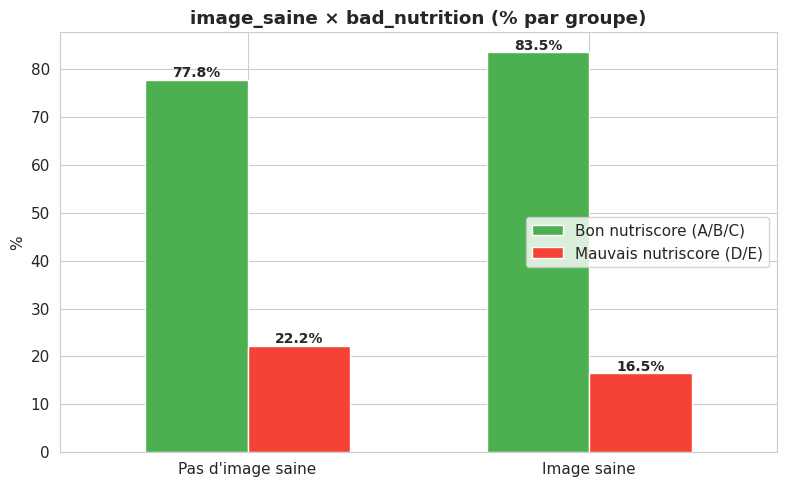

In [19]:
print('=== ANALYSE HEALTHY ILLUSION ===')
ct = pd.crosstab(df['image_saine'], df[TARGET])
ct.index = ['image_saine=0 (image pas saine)', 'image_saine=1 (image saine)']
ct.columns = ['bad=0 (bon nutriscore)', 'bad=1 (mauvais nutriscore)']
display(ct)

nb_image    = (df['image_saine'] == 1).sum()
nb_illusion = ((df['image_saine'] == 1) & (df[TARGET] == 1)).sum()
pct_ill     = nb_illusion / nb_image * 100 if nb_image > 0 else 0

print(f'\nParmi les {nb_image:,} produits avec image saine :')
print(f'  → {nb_illusion:,} ({pct_ill:.1f}%) ont un mauvais Nutri-Score = HEALTHY ILLUSION !')

# Graphique
ct_pct = pd.crosstab(df['image_saine'], df[TARGET], normalize='index') * 100
ct_pct.index = ["Pas d'image saine", 'Image saine']
ct_pct.columns = ['Bon (A/B/C)', 'Mauvais (D/E)']

fig, ax = plt.subplots(figsize=(8, 5))
ct_pct.plot(kind='bar', ax=ax, color=[COLOR_0, COLOR_1], edgecolor='white', width=0.6)
ax.set_title('image_saine × bad_nutrition (% par groupe)', fontweight='bold')
ax.set_ylabel('%')
ax.set_xticklabels(ct_pct.index, rotation=0)
ax.legend(['Bon nutriscore (A/B/C)', 'Mauvais nutriscore (D/E)'])
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x()+p.get_width()/2, p.get_height()+0.5),
                ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


## 13. Synthèse de l'EDA

Cette section résume les conclusions clés de l'analyse exploratoire et les actions à mener en Phase 2.


In [20]:
vc_t  = df[TARGET].value_counts()
pct_t = df[TARGET].value_counts(normalize=True) * 100

print('='*65)
print('SYNTHÈSE EDA — PROJET HEALTHY ILLUSION')
print('='*65)

print(f'''
1. DATASET
   - {len(df):,} produits alimentaires collectés via Open Food Facts API
   - {len(NUM_COLS)} features numériques + {len(CAT_COLS)} features catégorielles
   - Cible : bad_nutrition (Nutri-Score D/E → 1)

2. DÉSÉQUILIBRE
   - bad_nutrition = 0 (bon)     : {vc_t[0]:,} produits ({pct_t[0]:.1f}%)
   - bad_nutrition = 1 (mauvais) : {vc_t[1]:,} produits ({pct_t[1]:.1f}%)
   - Ratio déséquilibre : {vc_t[0]//vc_t[1]}:1 → rééquilibrage nécessaire en Phase 3
   - Stratégies prévues : class_weight, SMOTE, RandomUnderSampler

3. FEATURES SIGNAUX IDENTIFIÉES
   - Variables les plus discriminantes (Mann-Whitney p<0.001) : voir section 11
   - Ces variables seront prioritaires lors du feature engineering

4. VARIABLES À TRAITER EN PREPROCESSING
   - Valeurs manquantes : product_name (~1.8%), brands (~2.7%) → imputation
   - Haute cardinalité : country (101 modalités), brands (4801) → regroupement
   - Encodage : nutriscore_grade (ordinal A→E), main_category (one-hot)
   - Data leakage à éviter : exclure nutriscore_grade et healthy_illusion comme features

5. FEATURE ENGINEERING ENVISAGÉ (≥ 2 features pour la Phase 2)
   - sugar_fat_ratio : ratio sucres/graisses (signal d'un profil "junk food masqué")
   - nutri_additives_score : combinaison nutriscore ordinal × nombre d'additifs
   - energy_density_class : binning de energy_kcal_100g en tranches
   - protein_fiber_score : score des "bons" nutriments (protéines + fibres)
''')
print('='*65)
print(' Dataset validé — prêt pour 03_preprocessing.ipynb')
print('='*65)


SYNTHÈSE EDA — PROJET HEALTHY ILLUSION

1. DATASET
   - 15,079 produits alimentaires collectés via Open Food Facts API
   - 8 features numériques + 4 features catégorielles
   - Cible : bad_nutrition (Nutri-Score D/E → 1)

2. DÉSÉQUILIBRE
   - bad_nutrition = 0 (bon)     : 12,447 produits (82.5%)
   - bad_nutrition = 1 (mauvais) : 2,632 produits (17.5%)
   - Ratio déséquilibre : 4:1 → rééquilibrage nécessaire en Phase 3
   - Stratégies prévues : class_weight, SMOTE, RandomUnderSampler

3. FEATURES SIGNAUX IDENTIFIÉES
   - Variables les plus discriminantes (Mann-Whitney p<0.001) : voir section 11
   - Ces variables seront prioritaires lors du feature engineering

4. VARIABLES À TRAITER EN PREPROCESSING
   - Valeurs manquantes : product_name (~1.8%), brands (~2.7%) → imputation
   - Haute cardinalité : country (101 modalités), brands (4801) → regroupement
   - Encodage : nutriscore_grade (ordinal A→E), main_category (one-hot)
   - Data leakage à éviter : exclure nutriscore_grade et healt